In [104]:
import pandas as pd
import numpy as np

import xgboost as xgb
from datetime import datetime
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rc
import seaborn as sns
%matplotlib inline
#맥에서 한글 안깨지게


rc('font', family='AppleGothic') # 애플 폰트 사용
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 안깨지게 설정|

In [92]:
def visualization(model_name, y_test, pred, mae):
    """
        model_name : 모델명
        y_test : 테스트한 y
        pred : 예측값
        Mae : 모델의 MAE
    """
    plt.figure(figsize=(10,10))
    plt.scatter(y_test, pred, alpha=0.5, label='예측 결과')
    
    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    
    plt.plot([min_val, max_val], [min_val, max_val],
             '--r', linewidth=2, label='예측선')
    
    plt.xlabel("실제 면적당 단가 (만원)", fontsize=14)
    plt.ylabel("예측 면적당 단가 (만원)", fontsize=14)
    plt.title(f"{model_name}의 실제 가격 vs 예측 가격")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"{model_name}의 MAE : {mae:.5f}")

In [128]:
TABULAR_DATA_PATH = '../../data/interim/gang_nam_sendimental_score_with_sale.csv'
all_feature = np.load("../../data/final/all_feature.npy")

target =  df['면적당 단가(만원)']




In [76]:
df = pd.read_csv(TABULAR_DATA_PATH)
df.drop(columns=['sentiment_score'], axis=1, inplace=True)
df['계약일자'] = pd.to_datetime(df['계약일자'])
df.head(1)

,전용면적(㎡),층,건축년도,면적당 단가(만원),아파트 나이,계약일자,leading_index,건설기성액(백만원),부동산_소비심리지수,주택시장_소비심리지수,강남구_변동률,강남구_누계,토지시장_소비심리지수,아파트_호수,아파트_면적,rate
0,84.73,5,1994,7.399156,24,2018-07-01,94.7,11215836.0,111.9,113.4,0.692,2.975,98.3,183.0,18.0,1.5


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21561 entries, 0 to 21560
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   전용면적(㎡)        21561 non-null  float64       
 1   층              21561 non-null  int64         
 2   건축년도           21561 non-null  int64         
 3   면적당 단가(만원)     21561 non-null  float64       
 4   아파트 나이         21561 non-null  int64         
 5   계약일자           21561 non-null  datetime64[ns]
 6   leading_index  21561 non-null  float64       
 7   건설기성액(백만원)     21561 non-null  float64       
 8   부동산_소비심리지수     21561 non-null  float64       
 9   주택시장_소비심리지수    21561 non-null  float64       
 10  강남구_변동률        21561 non-null  float64       
 11  강남구_누계         21561 non-null  float64       
 12  토지시장_소비심리지수    21561 non-null  float64       
 13  아파트_호수         21561 non-null  float64       
 14  아파트_면적         21561 non-null  float64       
 15  rate           2156

In [78]:
df['year'] = df['계약일자'].dt.year
df['month'] = df['계약일자'].dt.month
df['day_of_week'] = df['계약일자'].dt.dayofweek


In [79]:
X = df.drop(['면적당 단가(만원)', '계약일자'], axis=1) # 예시 타겟 컬럼
y = df['면적당 단가(만원)']

In [80]:
split_point = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

In [81]:
# 3. 모델 학습 (이전과 동일)
xgb = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [82]:
xgb_pred = model.predict(X_test)

In [88]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
print(f"XGB의 MAE : {xgb_mae:.5f}")

XGB의 MAE : 0.16520


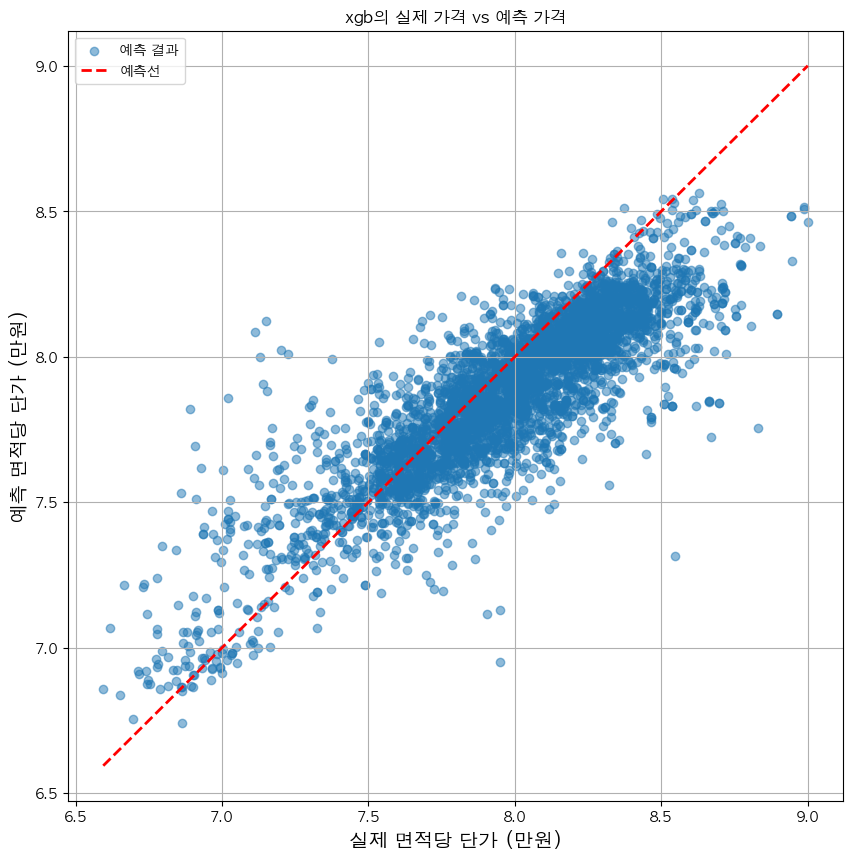

xgb의 MAE : 0.16520


In [91]:
visualization("xgb", y_test, xgb_pred, xgb_mae)

### 선형회귀

In [97]:
linear = LinearRegression()
linear.fit(X_train, y_train)
linear_pred = model.predict(X_test)
linear_mae = mean_absolute_error(y_test, linear_pred)

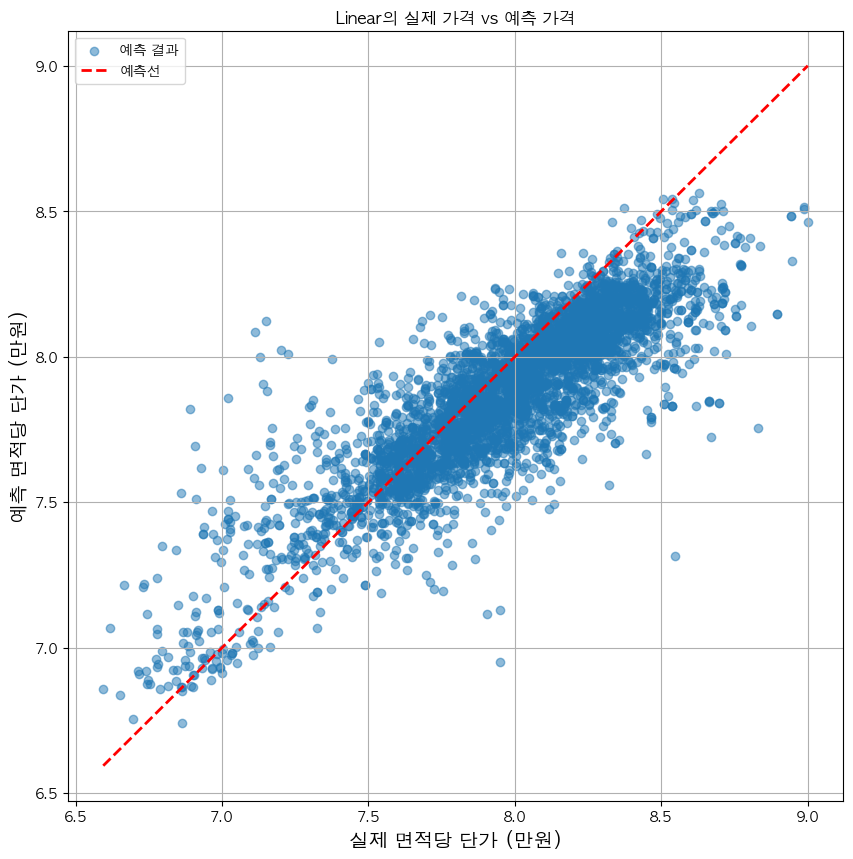

Linear의 MAE : 0.16520


In [96]:
visualization("Linear",y_test, linear_pred, linear_mae)

### RF

In [101]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)

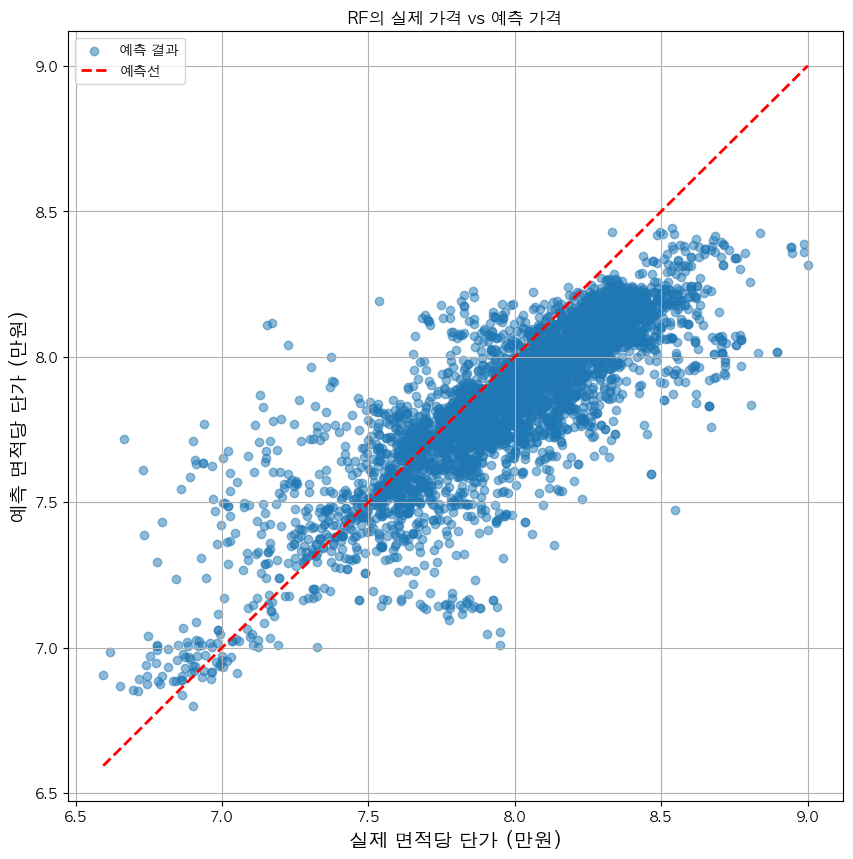

RF의 MAE : 0.18998


In [103]:
visualization("RF",y_test, rf_pred, rf_mae)

#### 벡터 먹이기

In [130]:
# 학습, 검증 데이터 나누기

n_train = int(len(all_feature) * 0.8)  # 80%를 학습
X_train, X_test = all_feature[:n_train], all_feature[n_train:]
y_train, y_test = target[:n_train], target[n_train:]

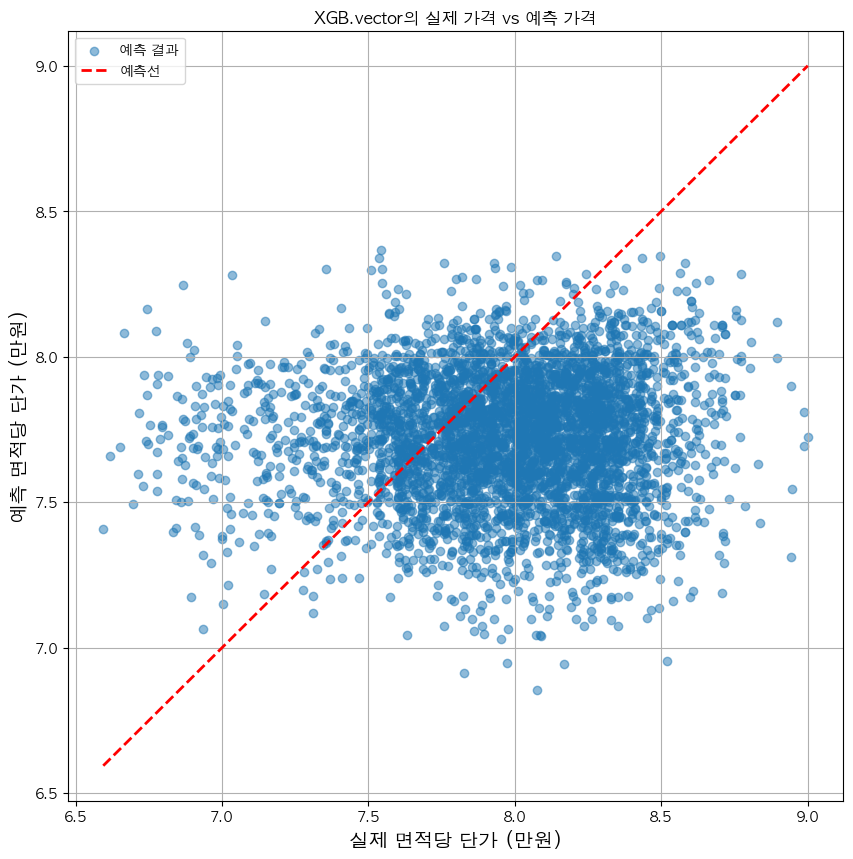

XGB.vector의 MAE : 0.40381


In [131]:
# XGB 회귀 모델
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# 예측 및 평가
xgb_pred = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)

visualization("XGB.vector",y_test, xgb_pred, xgb_mae)

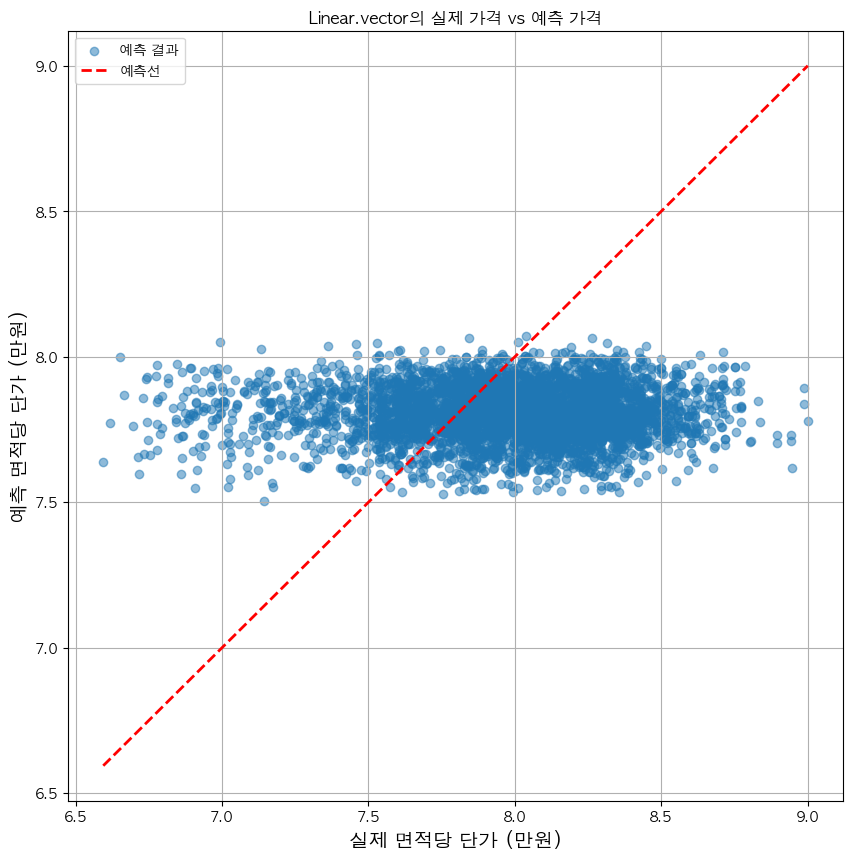

Linear.vector의 MAE : 0.33902


In [133]:
linear = LinearRegression()
linear.fit(X_train, y_train)

linear_pred = linear.predict(X_test)
linear_mae = mean_absolute_error(y_test, linear_pred)


visualization("Linear.vector",y_test, linear_pred, linear_mae)

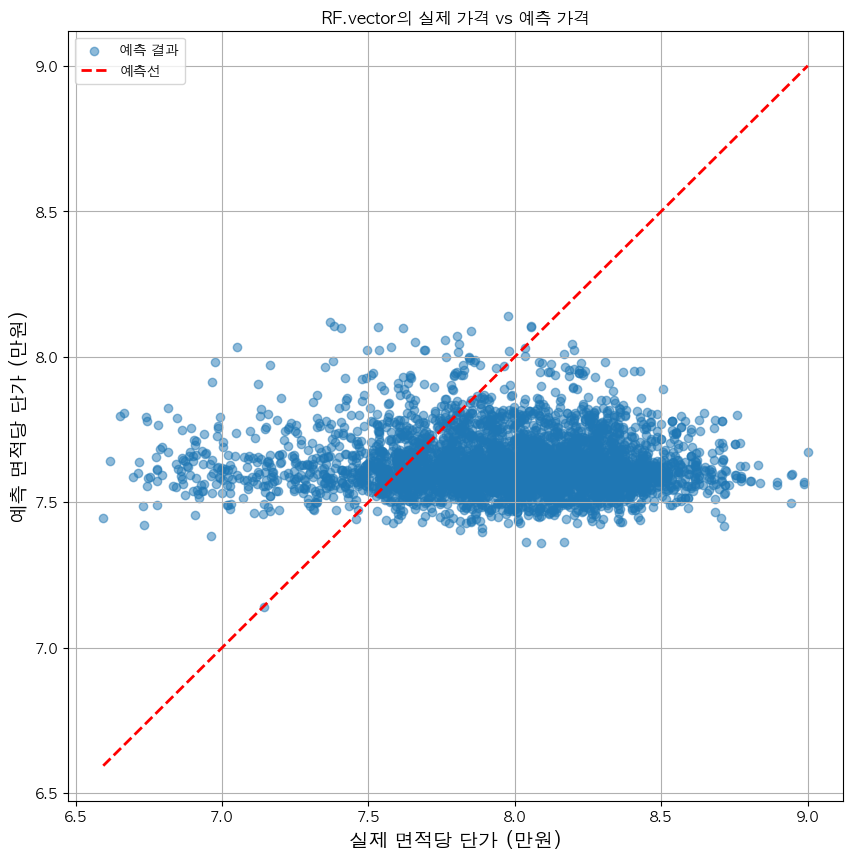

RF.vector의 MAE : 0.44254


In [134]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)

visualization("RF.vector",y_test, rf_pred, rf_mae)